In [15]:
import xarray as xr
import seaborn as sns
import warnings
import numpy as np
import scipy.stats as stats
from scipy.stats import pearsonr
from scipy.stats import gamma, norm
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import datetime
import matplotlib.pyplot as plt
import pickle
import cartopy.crs as ccrs
from sklearn.preprocessing import QuantileTransformer
import cartopy.feature as cfeature
from scipy.stats import spearmanr
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
import seaborn as sns
import os
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
from pathlib import Path
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
pd.options.mode.chained_assignment = None
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
base_path = os.path.expanduser("~/data/era5sgp/era5_sl_daily_total_precip_full_sgp")

# Collect all .nc files from 2001 to 2018

all_files = []

for year in range(1988, 2025):
    
    year_path = os.path.join(base_path, str(year))
    
    files = glob.glob(os.path.join(year_path, "*.nc"))
    
    all_files.extend(files)

In [5]:
# daily total precipitation for all grid points 

daily_p = xr.open_mfdataset(all_files, combine="by_coords")

daily_p['tp'] = daily_p['tp'] * 1000 # converting total precipitation from m to mm

In [16]:
# calculate sum of precipitation for every month and gridpoint in warm-season 

monthly_tp = daily_p['tp'].resample(valid_time='1MS').sum()

monthly_precip_df = monthly_tp.to_dataframe(name="monthly_tp").reset_index()

monthly_precip_df["year"] = monthly_precip_df["valid_time"].dt.year

monthly_precip_df["month"] = monthly_precip_df["valid_time"].dt.month

# filter for only warm-season

monthly_precip_df = monthly_precip_df[monthly_precip_df['month'].isin([5, 6, 7, 8, 9])]

In [38]:
warm_season_df = (
    monthly_precip_df
    .groupby(['latitude', 'longitude', 'year'])['monthly_tp']
    .sum()
    .reset_index()
    .rename(columns={'monthly_tp': 'warm_season_tp'})
)

for SPI calculation: 

we have data for days in: may, june, july, august, september for over 30 years 

for every gridpoint, calculate SPI for: may-june-july, june-july-august, july-august-september

take average of all three SPI's for every gridpoint

In [42]:
def compute_spi(group):
    
    # this should be shape = # of years because this groups by gridpoint and month 
    
    precip = group["warm_season_tp"].values
    
    # fit gamma distribution
    
    try:
        
        # alpha = shape
        # loc ("location") = shifts the entire distribution along the x-axis, 
        # beta = spread or range of the distribution
        
        fit_alpha, fit_loc, fit_beta = gamma.fit(precip, floc=0)  # loc=0
                
        cdf = gamma.cdf(precip, a=fit_alpha, loc=fit_loc, scale=fit_beta)
                    
        spi = norm.ppf(cdf)
    
    except Exception as e:
        
        print(f"Fit failed for group: {group.iloc[0][['latitude','longitude','month']].values}, error: {e}")

    group = group.copy()
    
    group["spi"] = spi
                  
    return group

In [51]:
spi_df = (warm_season_df.groupby(["latitude", "longitude"]).apply(compute_spi).reset_index(drop=True))

/tmp/ipykernel_49157/441565484.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spi_df = (warm_season_df.groupby(["latitude", "longitude"]).apply(compute_spi).reset_index(drop=True))


### choose a test year (drought, wet) to look at SPI on a map

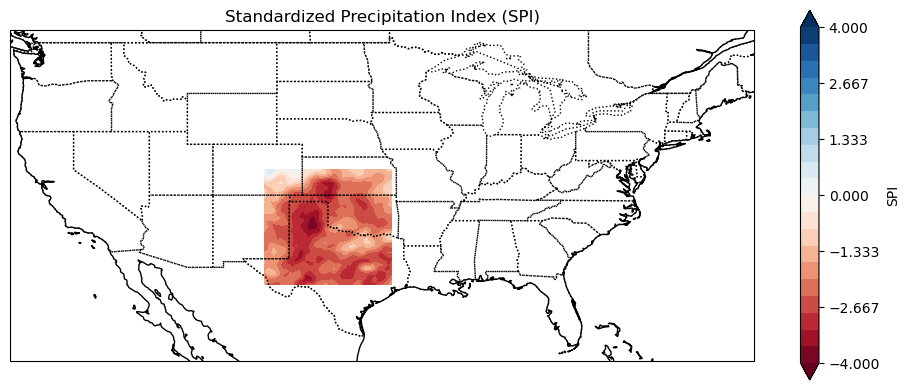

In [56]:
test_yr = spi_df[(spi_df['year'] == 2011)]

lon_unique = np.sort(test_yr['longitude'].unique())

lat_unique = np.sort(test_yr['latitude'].unique())

# Create 2D meshgrid
lon2d, lat2d = np.meshgrid(lon_unique, lat_unique)

# Interpolate scattered data onto the 2D grid
spi_grid = griddata(
    points=(test_yr['longitude'], test_yr['latitude']),
    values=test_yr['spi'],
    xi=(lon2d, lat2d),
    method='linear'
)

# Define normalization centered at 0
norm = mcolors.TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4)

fig = plt.figure(figsize=(12, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to CONUS (continental US)
ax.set_extent([-125, -66.5, 24, 50], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.COASTLINE)

ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.add_feature(cfeature.STATES, linestyle=':')

# Filled contour plot of SPI
cf = ax.contourf(
    lon2d, lat2d, spi_grid,
    levels=np.linspace(-4, 4, 21),  # smooth gradation
    cmap='RdBu',
    norm=norm,
    transform=ccrs.PlateCarree(),
    extend='both'
)

# Add colorbar
cb = plt.colorbar(cf, ax=ax, orientation='vertical', label='SPI', shrink=0.6)

cb.set_ticks(np.linspace(-4, 4, 7))

plt.title('Standardized Precipitation Index (SPI)')

plt.show()

In [98]:
# calculation warm-season domain average spi 

domain_average_spi = (spi_df.groupby(["year"])["spi"].mean().reset_index(name="spi"))

# gridpoint_spi = spi_df.copy()

# categorize years-months into SPI terciles

domain_average_spi["spi_tercile"] = pd.qcut(domain_average_spi["spi"], q=5, labels=["very dry", "dry", "normal", "wet", "very wet"])

# gridpoint_spi["spi_tercile"] = pd.qcut(gridpoint_spi["spi"], q=3, labels=["dry", "normal", "wet"])

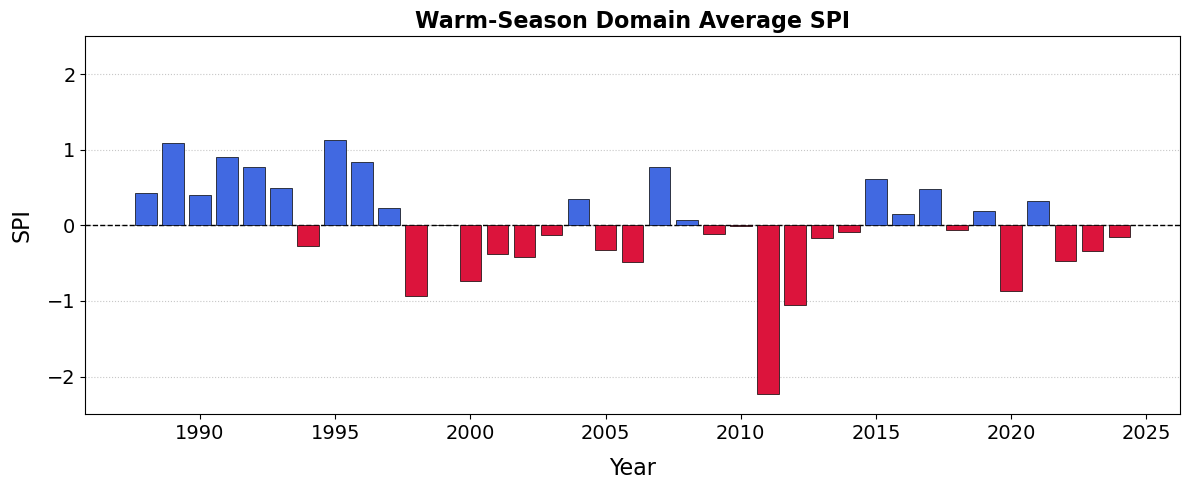

In [71]:
plt.figure(figsize=(12, 5))

# Color by sign of SPI
def spi_color(spi):
    
    return "crimson" if spi < 0 else "royalblue"

colors = domain_average_spi["spi"].apply(spi_color)

# Bar plot
plt.bar(domain_average_spi["year"], domain_average_spi["spi"], color=colors, zorder=3,
        edgecolor='black', linewidth=0.5)

# Zero line
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# Axis labels and title
plt.ylabel("SPI", fontsize=16, labelpad=10)

plt.xlabel("Year", fontsize=16, labelpad=10)

plt.title("Warm-Season Domain Average SPI", fontsize=16, weight='bold')  # title unchanged

# Ticks
plt.xticks(fontsize=14)

plt.yticks(fontsize=14)

# Y-axis range
plt.ylim(-2.5, 2.5)

# Grid
plt.grid(axis='y', linestyle=':', linewidth=0.8, alpha=0.7, zorder=0)

# Layout
plt.tight_layout()

plt.show()


#### reading in buoyancy

In [174]:
with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)
    
master['month'] = master['date'].dt.month

master['year'] = master['date'].dt.year

In [106]:
# # to hasten the join

# gridpoint_spi_filt = gridpoint_spi[(gridpoint_spi['year'] >= 2001) & (gridpoint_spi['year'] <= 2018)]

# # dry = gridpoint_spi_filt[gridpoint_spi_filt['spi_tercile'] == 'dry']

# # wet = gridpoint_spi_filt[gridpoint_spi_filt['spi_tercile'] == 'wet']

# buoyancy = master[["date", "year", "month", "latitude", "longitude", "blc_stnd_anom", "blt_stnd_anom"]]

# buoyancy = buoyancy.groupby(["year", "month", "latitude", "longitude"])[["blc_stnd_anom", "blt_stnd_anom"]].mean().reset_index()

In [175]:
master = master.merge(domain_average_spi[["year", "spi_tercile"]], on=["year"], how="left")

dry = master[(master['year'].isin([2011, 2012])) & (master['APE'] == False)]

nonapes = master[master['APE'] == False]

apes = master[master['APE'] == True]

wet = master[(master['year'].isin([2007, 2015])) & (master['APE'] == True)]

# buoyancy_w_spi = buoyancy.merge(gridpoint_spi_filt[["year", "month", "latitude", "longitude", "spi_tercile"]], 
#                       on = ["year", "month", "latitude", "longitude"], how="left")

# _2011 = master[(master['year'] == 2011)]

# _2007 = master[(master['year'] == 2007)]

# dry = buoyancy_w_spi[buoyancy_w_spi['spi_tercile'] == 'dry']

# wet = buoyancy_w_spi[buoyancy_w_spi['spi_tercile'] == 'wet']

# dry_terc_apes = master[(master['spi_tercile'] == 'dry') & (master['APE'] == True)]

# wet_terc_apes = master[(master['spi_tercile'] == 'wet') & (master['APE'] == True)]

In [34]:
# # --- Create string version of year_month for consistent x-axis labels ---
# _2007['year_month_str'] = _2007['year_month'].dt.strftime('%Y-%m')

# _2011['year_month_str'] = _2011['year_month'].dt.strftime('%Y-%m')

# # Group saturation counts by string version
# sat_2007 = (
#     _2007.groupby(['year_month_str', 'saturation'])
#          .size()
#          .unstack(fill_value=0)
#          .sort_index()
# )
# sat_2011 = (
#     _2011.groupby(['year_month_str', 'saturation'])
#          .size()
#          .unstack(fill_value=0)
#          .sort_index()
# )

# # Group anomalies and convert index to string
# anom_2007 = (
#     _2007.groupby('year_month')[['blt_stnd_anom', 'blc_stnd_anom']]
#          .mean()
#          .sort_index()
# )
# anom_2007.index = anom_2007.index.strftime('%Y-%m')

# anom_2011 = (
#     _2011.groupby('year_month')[['blt_stnd_anom', 'blc_stnd_anom']]
#          .mean()
#          .sort_index()
# )
# anom_2011.index = anom_2011.index.strftime('%Y-%m')

# # --- Colors ---
# anom_colors = {
#     'blt_stnd_anom': '#d62728',  # red
#     'blc_stnd_anom': '#1f77b4',  # blue
# }

# # --- Setup plot ---
# fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

# # --- Saturation bar plots ---
# sat_2007.plot(kind='bar', stacked=True, ax=axs[0, 0], colormap='Set2', legend=False)
# axs[0, 0].set_title("Saturation Categories Over Time (2007)", fontsize=16)
# axs[0, 0].set_ylabel("Count", fontsize=14)
# axs[0, 0].tick_params(axis='x', labelsize=14, rotation=45)

# sat_2011.plot(kind='bar', stacked=True, ax=axs[0, 1], colormap='Set2')
# axs[0, 1].set_title("Saturation Categories Over Time (2011)", fontsize=16)
# axs[0, 1].tick_params(axis='x', labelsize=14, rotation=45)
# axs[0, 1].legend(fontsize=14)

# # --- Anomaly plots ---
# anom_ymin = min(anom_2007.min().min(), anom_2011.min().min()) - 0.1
# anom_ymax = max(anom_2007.max().max(), anom_2011.max().max()) + 0.1

# # 2007
# for col in anom_2007.columns:
#     axs[1, 0].plot(
#         anom_2007.index,
#         anom_2007[col],
#         marker='o',
#         label=col.replace('_', ' ').upper(),
#         color=anom_colors[col],
#         linewidth=2
#     )

# axs[1, 0].axhline(0, color='gray', linestyle='--', linewidth=1)
# axs[1, 0].set_title("Monthly Avg BLT and BLC Anomalies (2007)", fontsize=16)
# axs[1, 0].set_ylabel("Standardized Anomaly", fontsize=14)
# axs[1, 0].set_ylim(anom_ymin, anom_ymax)
# axs[1, 0].grid(True, linestyle='--', alpha=0.4)
# axs[1, 0].tick_params(axis='x', labelsize=14, rotation=45)
# axs[1, 0].set_xticks(sat_2007.index)  # sync with bar plot x-axis
# axs[1, 0].set_xticklabels(sat_2007.index)
# axs[1, 0].legend(fontsize=14)

# # 2011
# for col in anom_2011.columns:
#     axs[1, 1].plot(
#         anom_2011.index,
#         anom_2011[col],
#         marker='o',
#         label=col.replace('_', ' ').upper(),
#         color=anom_colors[col],
#         linewidth=2
#     )

# axs[1, 1].axhline(0, color='gray', linestyle='--', linewidth=1)
# axs[1, 1].set_title("Monthly Avg BLT and BLC Anomalies (2011)", fontsize=16)
# axs[1, 1].set_ylim(anom_ymin, anom_ymax)
# axs[1, 1].grid(True, linestyle='--', alpha=0.4)
# axs[1, 1].tick_params(axis='x', labelsize=14, rotation=45)
# axs[1, 1].set_xticks(sat_2011.index)
# axs[1, 1].set_xticklabels(sat_2011.index)
# axs[1, 1].legend(fontsize=14)

# # --- Final formatting ---
# plt.tight_layout()

# plt.show()

In [176]:
# # gridpoint average blc and blt standardized anomaly

dry_grouped = dry.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

wet_grouped = wet.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

apes_grouped = apes.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

nonapes_grouped = nonapes.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

# dry_terc_apes_grouped = dry_terc_apes.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

# wet_terc_apes_grouped = wet_terc_apes.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

# _2011_grouped = _2011.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

# _2007_grouped = _2007.groupby(["latitude", "longitude"], as_index=False)[['blc_stnd_anom', 'blt_stnd_anom']].mean()

In [80]:
# _2011_grouped = _2011_grouped.rename(columns={
#     "blc_stnd_anom": "blc_2011",
#     "blt_stnd_anom": "blt_2011"
# })

# _2007_grouped = _2007_grouped.rename(columns={
#     "blc_stnd_anom": "blc_2007",
#     "blt_stnd_anom": "blt_2007"
# })


# dry_grouped = dry_grouped.rename(columns={
#     "blc_stnd_anom": "blc_dry",
#     "blt_stnd_anom": "blt_dry"
# })

# wet_grouped = wet_grouped.rename(columns={
#     "blc_stnd_anom": "blc_wet",
#     "blt_stnd_anom": "blt_wet"
# })

# dry_terc_apes_grouped = dry_terc_apes_grouped.rename(columns={
#     "blc_stnd_anom": "blc_dry",
#     "blt_stnd_anom": "blt_dry"
# })

# wet_terc_apes_grouped = wet_terc_apes_grouped.rename(columns={
#     "blc_stnd_anom": "blc_wet",
#     "blt_stnd_anom": "blt_wet"
# })


# Step 2: Merge on lat/lon

# drought_minus_wet = pd.merge(_2007_grouped, _2011_grouped, on=["latitude", "longitude"], how="inner")

# wet_minus_dry = pd.merge(dry_grouped, wet_grouped, on=["latitude", "longitude"], how="inner")

# wet_minus_dry_apes = pd.merge(dry_terc_apes_grouped, wet_terc_apes_grouped, on=["latitude", "longitude"], how="inner")

# Step 3: Compute differences

# drought_minus_wet["blc_diff"] = drought_minus_wet["blc_2011"] - drought_minus_wet["blc_2007"]

# drought_minus_wet["blt_diff"] = drought_minus_wet["blt_2011"] - drought_minus_wet["blt_2007"]

# Step 3: Compute differences

# wet_minus_dry["blc_diff"] = wet_minus_dry["blc_wet"] - wet_minus_dry["blc_dry"]

# wet_minus_dry["blt_diff"] = wet_minus_dry["blt_wet"] - wet_minus_dry["blt_dry"]

# Step 3: Compute differences

# wet_minus_dry_apes["blc_diff"] = wet_minus_dry_apes["blc_wet"] - wet_minus_dry_apes["blc_dry"]

# wet_minus_dry_apes["blt_diff"] = wet_minus_dry_apes["blt_wet"] - wet_minus_dry_apes["blt_dry"]

In [113]:
dry_sampled = dry.sample(n=3000, random_state=42)

wet_sampled = wet.sample(n=3000, random_state=42)

### JOINT FREQUENCY DISTRIBUTION FOR DRY TERCILES

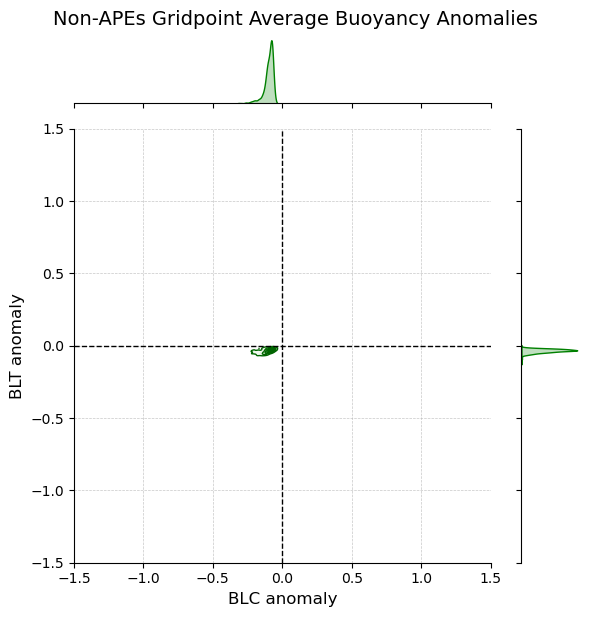

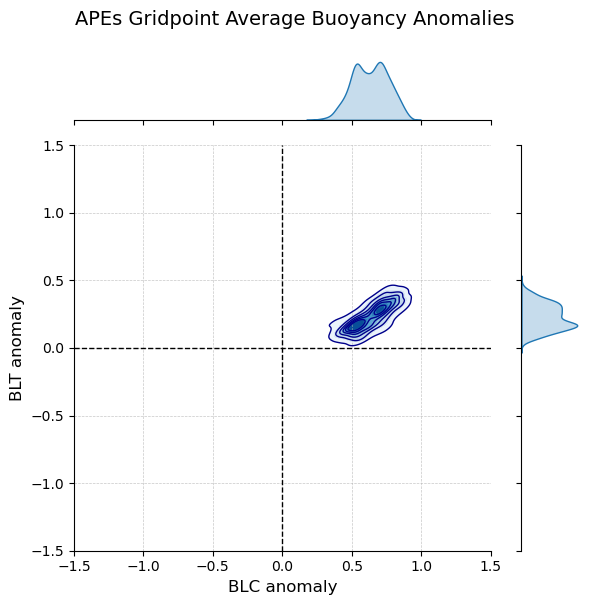

In [182]:
## nonapes_grouped TERCILE BELOW 

g = sns.JointGrid(
    
    x=nonapes_grouped['blc_stnd_anom'],
    
    y=nonapes_grouped['blt_stnd_anom'],
)


sns.kdeplot(
    
    x=nonapes_grouped['blc_stnd_anom'],
    
    y=nonapes_grouped['blt_stnd_anom'],
    
    cmap="Greens",
    
    fill=True,
    
    ax=g.ax_joint, 

)

# filled density

sns.kdeplot(
    
    x=nonapes_grouped['blc_stnd_anom'],
    
    y=nonapes_grouped['blt_stnd_anom'],
    
    cmap="Greens",
    
    fill=True,
    
    ax=g.ax_joint,
    
    alpha=0.7
)

# Contour lines
sns.kdeplot(
    
    x=nonapes_grouped['blc_stnd_anom'],
    
    y=nonapes_grouped['blt_stnd_anom'],
    
    color="darkgreen",
    
    linewidths=1,
    
    levels=7,       # number of contour lines
    
    ax=g.ax_joint
)


ax_lim = 1.5

# Marginals

sns.kdeplot(x=nonapes_grouped['blc_stnd_anom'], fill=True, ax=g.ax_marg_x, color='green')

sns.kdeplot(y=nonapes_grouped['blt_stnd_anom'], fill=True, ax=g.ax_marg_y, color='green')

# Add 0 lines to the joint plot

g.ax_joint.axhline(0, color="k", linestyle="--", linewidth=1)

g.ax_joint.axvline(0, color="k", linestyle="--", linewidth=1)

# Axis labels

g.set_axis_labels("BLC anomaly", "BLT anomaly", fontsize=12)

# Set x and y limits on the joint axis

g.ax_joint.set_xlim(-ax_lim, ax_lim)

g.ax_joint.set_ylim(-ax_lim, ax_lim)

plt.tight_layout()

g.ax_joint.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.suptitle("Non-APEs Gridpoint Average Buoyancy Anomalies", ha='center', va='top', y=1.02, fontsize=14)

plt.show()


# apes_grouped TERCILE BELOW 

# Create JointGrid
g = sns.JointGrid(
    
    x=apes_grouped['blc_stnd_anom'],
    
    y=apes_grouped['blt_stnd_anom'],
)

# Joint KDE
sns.kdeplot(
    
    x=apes_grouped['blc_stnd_anom'],
    
    y=apes_grouped['blt_stnd_anom'],
    
    cmap="Blues",
    
    ax=g.ax_joint, 
    
    fill=True
)

# filled density

sns.kdeplot(
    
    x=apes_grouped['blc_stnd_anom'],
    
    y=apes_grouped['blt_stnd_anom'],
    
    cmap="Blues",
    
    fill=True,
    
    ax=g.ax_joint,
    
    alpha=0.7
)

# Contour lines
sns.kdeplot(
    
    x=apes_grouped['blc_stnd_anom'],
    
    y=apes_grouped['blt_stnd_anom'],
    
    color="darkblue",
    
    linewidths=1,
    
    levels=7,       # number of contour lines
    
    ax=g.ax_joint
)

# Marginals

sns.kdeplot(x=apes_grouped['blc_stnd_anom'], fill=True, ax=g.ax_marg_x)

sns.kdeplot(y=apes_grouped['blt_stnd_anom'], fill=True, ax=g.ax_marg_y)

# Add 0 lines to the joint plot
g.ax_joint.axhline(0, color="k", linestyle="--", linewidth=1)

g.ax_joint.axvline(0, color="k", linestyle="--", linewidth=1)

g.ax_joint.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Axis labels
g.set_axis_labels("BLC anomaly", "BLT anomaly", fontsize=12)

plt.suptitle("APEs Gridpoint Average Buoyancy Anomalies", ha='center', va='top', y=1, fontsize=14)

g.ax_joint.set_xlim(-ax_lim, ax_lim)

g.ax_joint.set_ylim(-ax_lim, ax_lim)

plt.tight_layout()

plt.show()

In [149]:
blt_neg = master[master['blt_stnd_anom'] < 0]

blt_pos = master[master['blt_stnd_anom'] > 0]

In [201]:
var = 'drycoupling'

print("blt negative", (blt_neg[var].sum() / len(blt_neg[var])) * 100) 

print("")

print("when blt is positive ", (blt_pos[var].sum() / len(blt_pos[var])) * 100, "percent of the time it is var")

blt negative 13.035740560724218

blt positive 23.273263204613926


In [203]:
master = master[master["daily_precip"].apply(lambda x: len(x) == 24)]

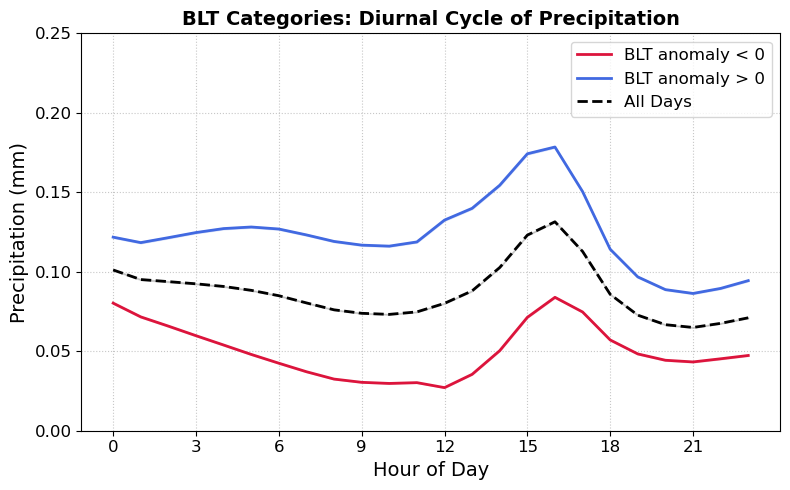

In [229]:
# Step 2: Split into negative and positive BLT anomalies
neg = master[master["blt_stnd_anom"] < 0]["daily_precip"]

pos = master[master["blt_stnd_anom"] > 0]["daily_precip"]

# Convert to arrays
neg_arr = np.vstack(neg.values)

pos_arr = np.vstack(pos.values)

# Step 3: Compute mean for neg/pos
avg_neg = np.mean(neg_arr, axis=0)

avg_pos = np.mean(pos_arr, axis=0)


# Step 4: Compute standard error for neg/pos
se_neg = np.std(neg_arr, axis=0, ddof=1) / np.sqrt(neg_arr.shape[0])

se_pos = np.std(pos_arr, axis=0, ddof=1) / np.sqrt(pos_arr.shape[0])

# Step 5: Compute overall mean & SE
all_arr = np.vstack(master["daily_precip"].values)

avg_all = np.mean(all_arr, axis=0)

se_all = np.std(all_arr, axis=0, ddof=1) / np.sqrt(all_arr.shape[0])

# Step 6: X-axis (hours)
hours = np.arange(0, 24)

# Step 7: Plot
plt.figure(figsize=(8, 5))

# Lines
plt.plot(hours, avg_neg, label="BLT anomaly < 0", color="crimson", linewidth=2)

plt.plot(hours, avg_pos, label="BLT anomaly > 0", color="royalblue", linewidth=2)

plt.plot(hours, avg_all, label="All Days", color="black", linewidth=2, linestyle="--")

# Shaded error bands
plt.fill_between(hours, avg_neg - se_neg, avg_neg + se_neg, color="crimson", alpha=0.2)

plt.fill_between(hours, avg_pos - se_pos, avg_pos + se_pos, color="royalblue", alpha=0.2)

plt.fill_between(hours, avg_all - se_all, avg_all + se_all, color="black", alpha=0.15)

# Styling
plt.xlabel("Hour of Day", fontsize=14)

plt.ylabel("Precipitation (mm)", fontsize=14)

plt.title("BLT Categories: Diurnal Cycle of Precipitation", fontsize=14, weight="bold")

plt.legend(fontsize=12)

plt.grid(True, linestyle=":", alpha=0.7)

plt.xticks(np.arange(0, 24, 3), fontsize=12)

plt.yticks(fontsize=12)

plt.tight_layout()

plt.ylim(0, 0.25)

plt.show()

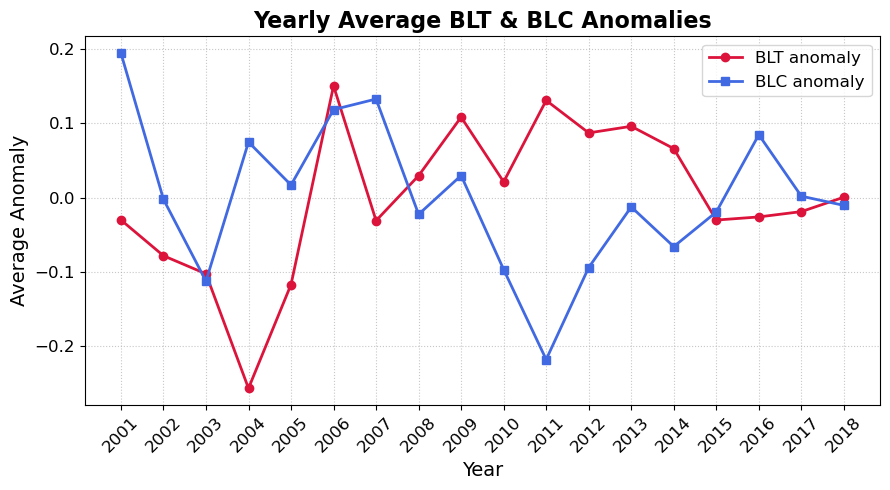

In [221]:
# Step 1: Group by year and take the mean
yearly_means = master.groupby("year")[["blt_stnd_anom", "blc_stnd_anom"]].mean()

# Step 2: Plot
plt.figure(figsize=(9, 5))

plt.plot(yearly_means.index, yearly_means["blt_stnd_anom"], marker="o", color="crimson", linewidth=2, label="BLT anomaly")

plt.plot(yearly_means.index, yearly_means["blc_stnd_anom"], marker="s", color="royalblue", linewidth=2, label="BLC anomaly")

# Styling
plt.xlabel("Year", fontsize=14)

plt.ylabel("Average Anomaly", fontsize=14)

plt.title("Yearly Average BLT & BLC Anomalies", fontsize=16, weight="bold")

plt.legend(fontsize=12)

plt.grid(True, linestyle=":", alpha=0.7)

plt.xticks(yearly_means.index, rotation=45, fontsize=12)

plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()


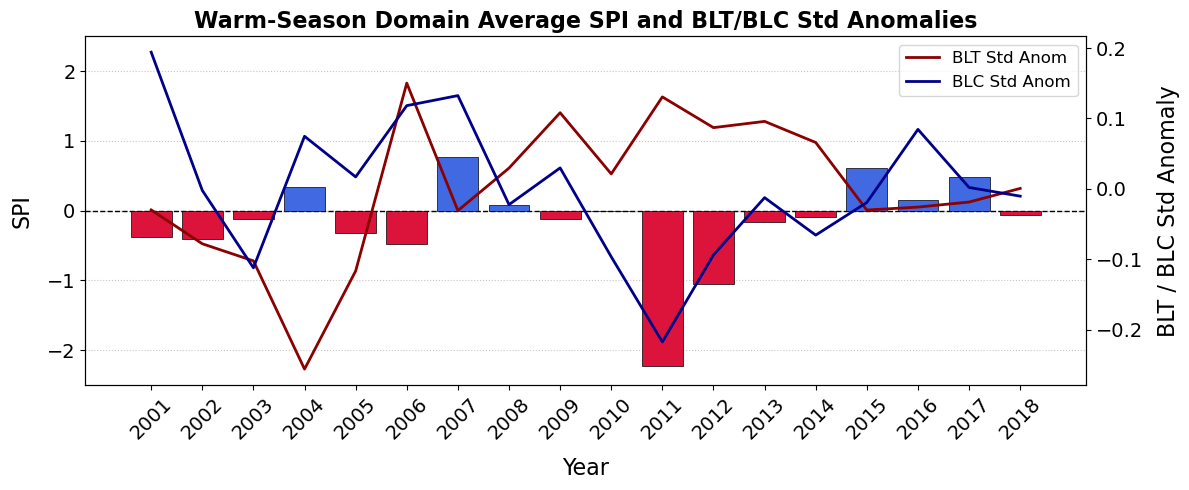

In [222]:
import matplotlib.pyplot as plt

# Step 1: Calculate yearly means for BLT/BLC
blt_blc_yearly = master.groupby("year")[["blt_stnd_anom", "blc_stnd_anom"]].mean()

# Ensure the years match between SPI and BLT/BLC data
min_year = blt_blc_yearly.index.min()
max_year = blt_blc_yearly.index.max()

spi_data = domain_average_spi[
    (domain_average_spi["year"] >= min_year) &
    (domain_average_spi["year"] <= max_year)
]

# Step 2: Create plot
fig, ax1 = plt.subplots(figsize=(12, 5))

# --- SPI bars ---
def spi_color(spi):
    return "crimson" if spi < 0 else "royalblue"

colors = spi_data["spi"].apply(spi_color)
ax1.bar(spi_data["year"], spi_data["spi"], color=colors, zorder=3,
        edgecolor='black', linewidth=0.5)
ax1.axhline(0, color="black", linestyle="--", linewidth=1)

# Labels for left y-axis (SPI)
ax1.set_ylabel("SPI", fontsize=16, labelpad=10)
ax1.set_xlabel("Year", fontsize=16, labelpad=10)
ax1.set_ylim(-2.5, 2.5)
ax1.tick_params(axis='y', labelsize=14)
ax1.grid(axis='y', linestyle=':', linewidth=0.8, alpha=0.7, zorder=0)

# --- BLT/BLC lines ---
ax2 = ax1.twinx()  # right y-axis
ax2.plot(blt_blc_yearly.index, blt_blc_yearly["blt_stnd_anom"], color="darkred",
         label="BLT Std Anom", linewidth=2)
ax2.plot(blt_blc_yearly.index, blt_blc_yearly["blc_stnd_anom"], color="darkblue",
         label="BLC Std Anom", linewidth=2)
ax2.set_ylabel("BLT / BLC Std Anomaly", fontsize=16, labelpad=10)
ax2.tick_params(axis='y', labelsize=14)

# --- Legend ---
lines_labels = ax2.get_legend_handles_labels()
ax2.legend(*lines_labels, loc="upper right", fontsize=12)

# --- Title & ticks ---
plt.title("Warm-Season Domain Average SPI and BLT/BLC Std Anomalies",
          fontsize=16, weight='bold')
ax1.set_xticks(spi_data["year"])
ax1.set_xticklabels(spi_data["year"], rotation=45, fontsize=14)

plt.tight_layout()
plt.show()
